In [3]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\Dell\Desktop\E-commerce-Customer-Sales-Intelligence\data\online_retail_II.csv"

df = pd.read_csv(file_path, encoding="latin1")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (525461, 9)

Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'price', 'Customer ID', 'Country', 'Revenue=Quantity_cell*UnitPrice_cell']


,Invoice,StockCode,Description,Quantity,InvoiceDate,price,Customer ID,Country,Revenue=Quantity_cell*UnitPrice_cell
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom,30.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Invoice                               525461 non-null  object 
 1   StockCode                             525461 non-null  object 
 2   Description                           522534 non-null  object 
 3   Quantity                              525461 non-null  int64  
 4   InvoiceDate                           525461 non-null  object 
 5   price                                 525461 non-null  float64
 6   Customer ID                           417534 non-null  float64
 7   Country                               525461 non-null  object 
 8   Revenue=Quantity_cell*UnitPrice_cell  525461 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 36.1+ MB


In [5]:
df.describe()

,Quantity,price,Customer ID,Revenue=Quantity_cell*UnitPrice_cell
count,525461.000000,525461.000000,417534.000000,525461.000000
mean,10.337667,4.688834,15360.645478,18.154506
std,107.424110,146.126914,1680.811316,160.333083
min,-9600.000000,-53594.360000,12346.000000,-53594.360000
25%,1.000000,1.250000,13983.000000,3.750000
50%,3.000000,2.100000,15311.000000,9.950000
75%,10.000000,4.210000,16799.000000,17.700000
max,19152.000000,25111.090000,18287.000000,25111.090000


In [6]:
df.shape

(525461, 9)

In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'price', 'Customer ID', 'Country',
       'Revenue=Quantity_cell*UnitPrice_cell'],
      dtype='object')

In [8]:
print(df.isnull().sum())

Invoice                                      0
StockCode                                    0
Description                               2927
Quantity                                     0
InvoiceDate                                  0
price                                        0
Customer ID                             107927
Country                                      0
Revenue=Quantity_cell*UnitPrice_cell         0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6865


In [10]:
df[df.duplicated(keep=False)].sort_values(
    by=["Invoice", "StockCode"]
).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,price,Customer ID,Country,Revenue=Quantity_cell*UnitPrice_cell
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,01-12-2009 11:34,1.95,16329.0,United Kingdom,1.95
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,01-12-2009 11:34,1.95,16329.0,United Kingdom,1.95
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,01-12-2009 11:34,3.75,16329.0,United Kingdom,3.75
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,01-12-2009 11:34,3.75,16329.0,United Kingdom,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,01-12-2009 11:34,3.75,16329.0,United Kingdom,3.75
371,489517,21912,VINTAGE SNAKES & LADDERS,1,01-12-2009 11:34,3.75,16329.0,United Kingdom,3.75
394,489517,21912,VINTAGE SNAKES & LADDERS,1,01-12-2009 11:34,3.75,16329.0,United Kingdom,3.75
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,01-12-2009 11:34,3.75,16329.0,United Kingdom,3.75
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,01-12-2009 11:34,3.75,16329.0,United Kingdom,3.75
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,01-12-2009 11:34,0.85,16329.0,United Kingdom,5.10


In [11]:
print("Before:", df.shape)   #First, let's record the original size:

Before: (525461, 9)


In [12]:
df = df.drop_duplicates().copy()  #Then remove exact duplicates:

In [13]:
#Then verify:
print("After:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

After: (518596, 9)
Duplicates remaining: 0


In [14]:
df.isna().sum()

Invoice                                      0
StockCode                                    0
Description                               2927
Quantity                                     0
InvoiceDate                                  0
price                                        0
Customer ID                             107833
Country                                      0
Revenue=Quantity_cell*UnitPrice_cell         0
dtype: int64

In [15]:
#Clean the missing Description, We have 2,927 missing descriptions.
#For our sales/customer analysis, we don't need to guess what those products are. 
# We'll remove rows where Description is missing.
df = df.dropna(subset=["Description"]).copy()

print("Shape after removing missing descriptions:", df.shape)

Shape after removing missing descriptions: (515669, 9)


In [16]:
#Customer ID , We have 107,927 missing Customer IDs.
#Do NOT delete those rows. because Why? They can still be useful for overall sales/revenue analysis, 
# even though we cannot use them for customer-level RFM/churn analysis.
#So we'll create a separate customer-analysis dataset later.
df["Revenue"] = df["Quantity"] * df["price"]
print(df[["Quantity", "price", "Revenue"]].head())

   Quantity  price  Revenue
0        12   6.95     83.4
1        12   6.75     81.0
2        12   6.75     81.0
3        48   2.10    100.8
4        24   1.25     30.0


In [17]:
#Check the result
print("Total Revenue:", df["Revenue"].sum())
print("Negative Revenue:", (df["Revenue"] < 0).sum())

Total Revenue: 9505775.564000001
Negative Revenue: 10184


In [18]:
#prepare data
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

print("Missing dates:", df["InvoiceDate"].isna().sum())
print("Minimum date:", df["InvoiceDate"].min())
print("Maximum date:", df["InvoiceDate"].max())

Missing dates: 301798
Minimum date: 2009-01-12 07:45:00
Maximum date: 2010-12-11 17:32:00


In [19]:
#Monthly revenue
monthly_sales = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Month", "Revenue"]

monthly_sales

,Month,Revenue
0,2009-01,53010.760
1,2009-02,62583.660
2,2009-03,68027.590
3,2009-04,40195.800
4,2009-05,9803.050
5,2009-06,24126.580
6,2009-07,44169.880
7,2009-08,43702.140
8,2009-09,40046.120
9,2009-10,43134.330


In [20]:
#Find the best month
monthly_sales.loc[monthly_sales["Revenue"].idxmax()]

Month         2010-08
Revenue    417748.301
Name: 18, dtype: object

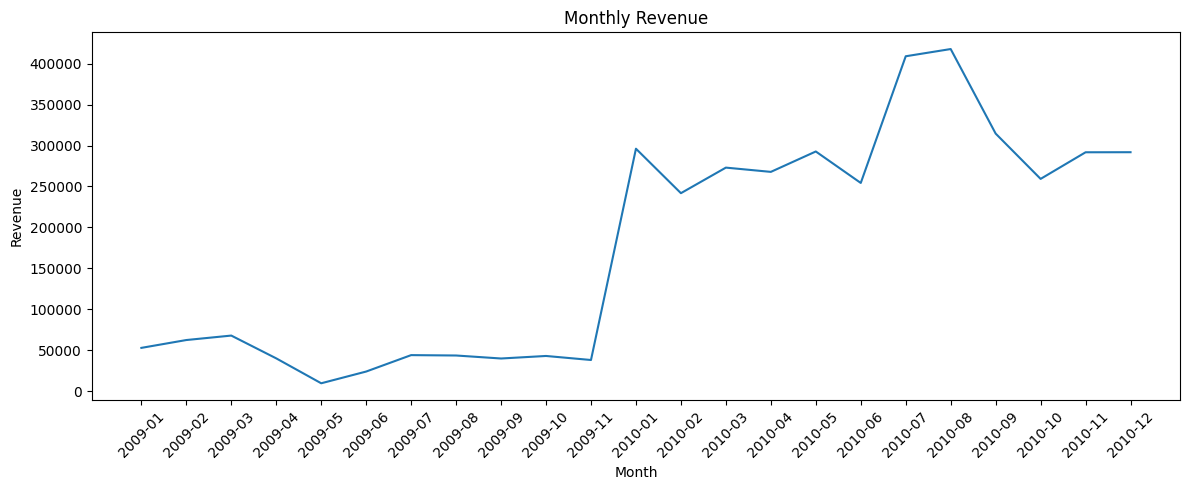

In [21]:
#Plot it
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["Month"].astype(str), monthly_sales["Revenue"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [22]:
#Top products by revenue
top_products = (
    df.groupby("StockCode")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

StockCode
22423     162885.71
85123A    155540.37
DOT       116401.99
85099B     88784.03
84879      72251.32
22086      57808.25
47566      49626.92
84347      47641.89
POST       46092.36
21843      42073.15
Name: Revenue, dtype: float64

In [23]:
#Make it easier to understand, Let's include the product description:
top_products = (
    df.groupby(["StockCode", "Description"])["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_products

,StockCode,Description,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,162885.71
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,155540.37
2,DOT,DOTCOM POSTAGE,116401.99
3,84879,ASSORTED COLOUR BIRD ORNAMENT,72251.32
4,22086,PAPER CHAIN KIT 50'S CHRISTMAS,57808.25
5,85099B,JUMBO BAG RED RETROSPOT,54217.92
6,47566,PARTY BUNTING,49626.92
7,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47641.89
8,POST,POSTAGE,46092.36
9,85099F,JUMBO BAG STRAWBERRY,35823.39


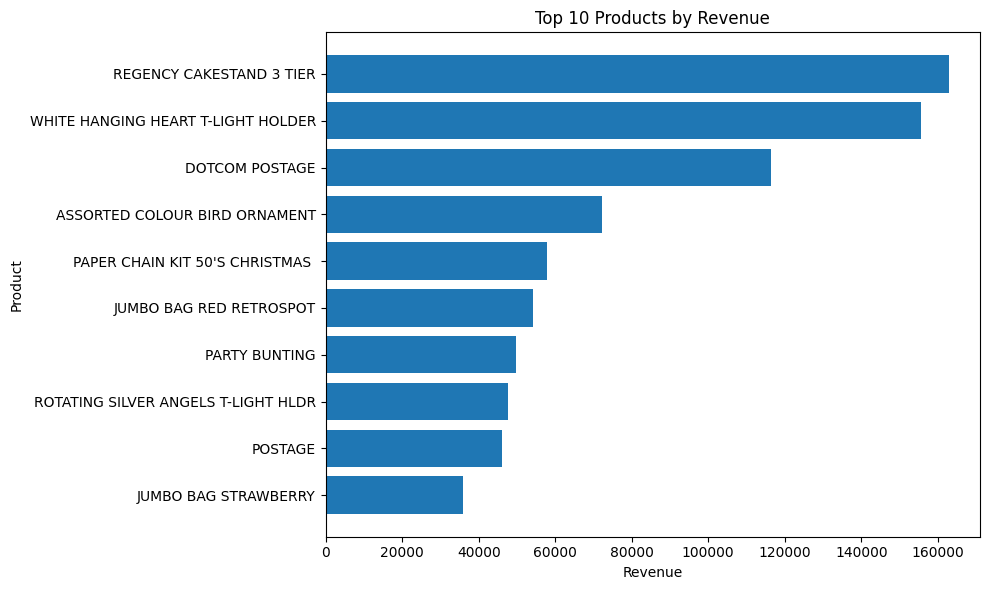

In [24]:
#Visualize
plt.figure(figsize=(10, 6))

plt.barh(
    top_products["Description"].astype(str),
    top_products["Revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
#Revenue by country
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

country_sales.head(10)

,Country,Revenue
0,United Kingdom,8161692.763
1,EIRE,352235.680
2,Netherlands,263861.760
3,Germany,195920.421
4,France,130661.550
5,Sweden,51190.110
6,Denmark,46972.950
7,Switzerland,43343.410
8,Spain,37052.130
9,Australia,30051.800


In [26]:
#Number of transactions by country
country_transactions = (
    df.groupby("Country")["Invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

country_transactions

Country
United Kingdom    23706
Germany             513
EIRE                457
France              297
Netherlands         150
Spain                85
Sweden               83
Belgium              65
Portugal             57
Switzerland          50
Name: Invoice, dtype: int64

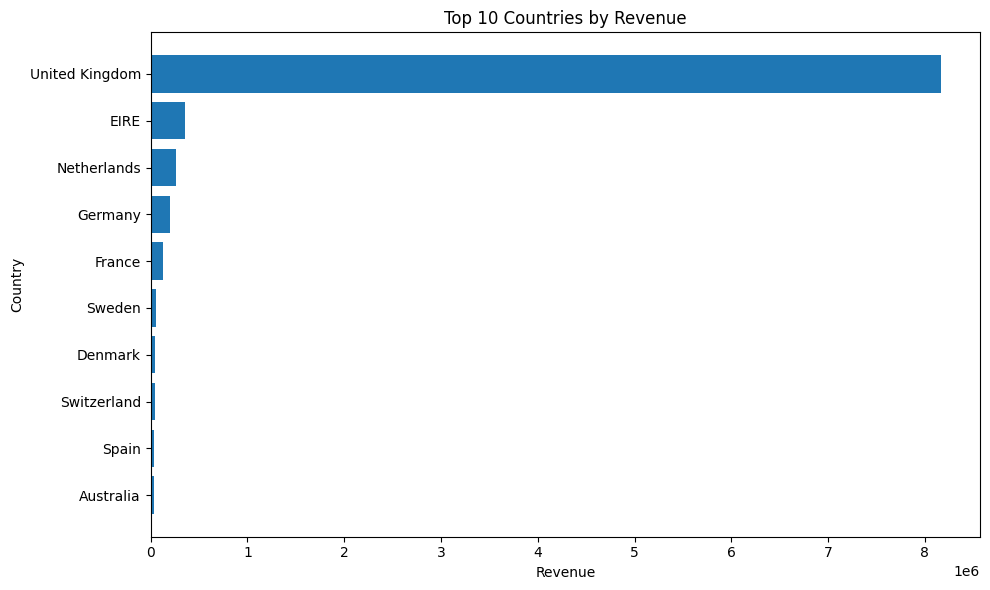

In [27]:
#Plot top countries
plt.figure(figsize=(10, 6))

plt.barh(
    country_sales.head(10)["Country"],
    country_sales.head(10)["Revenue"]
)

plt.xlabel("Revenue")
plt.ylabel("Country")
plt.title("Top 10 Countries by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [28]:
#Create a customer-level dataset
customer_df = df.dropna(subset=["Customer ID"]).copy()
print("Customer records:", customer_df.shape)
print("Unique customers:", customer_df["Customer ID"].nunique())

Customer records: (410763, 10)
Unique customers: 4383


In [29]:
#Find the analysis date
analysis_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Analysis date:", analysis_date)

Analysis date: 2010-12-12 17:01:00
